In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [3]:
def load_repo_rate(path, target_index=None):
    raw = pd.read_excel(path, header=None)
    header_row_idx = raw[raw.apply(
        lambda row: row.astype(str).str.contains('Effective Date').any(), axis=1
    )].index[0]
    data = raw.iloc[header_row_idx + 3:].copy()
    data.columns = ['blank', 'eff_date', 'bank_rate', 'repo', 'reverse_repo',
                     'sdf', 'msf', 'crr', 'slr']
    data = data.drop(columns='blank')
    data['eff_date'] = pd.to_datetime(data['eff_date'], errors='coerce')
    data = data.dropna(subset=['eff_date'])
    data['repo'] = pd.to_numeric(data['repo'], errors='coerce')
    repo_changes = data[['eff_date', 'repo']].dropna().sort_values('eff_date')
    repo_changes = repo_changes.set_index('eff_date')['repo']
    repo_changes = repo_changes[~repo_changes.index.duplicated(keep='last')]
    if target_index is not None:
        full_range = pd.date_range(
            start=min(repo_changes.index.min(), target_index.min()),
            end=target_index.max(), freq='D')
        repo_daily = repo_changes.reindex(full_range).ffill().reindex(target_index)
    else:
        repo_daily = repo_changes
    repo_daily.name = 'repo_rate'
    return repo_daily

In [4]:
consolidated = pd.read_excel('data/consolidated_macro_daily_2021-07-01_to_2025-12-31_FILLED_v2.xlsx')
consolidated['Date'] = pd.to_datetime(consolidated['Date'])
consolidated = consolidated.rename(columns={
    'SOFR':'sofr', 'USDINR':'usdinr', 'US10Y':'us_10y', 'INDIA10Y':'india_10y'
}).set_index('Date')
consolidated = consolidated.drop(columns=['WPI', 'CPI'], errors='ignore')

print(consolidated.shape)
print(consolidated.columns.tolist())

(1121, 5)
['sofr', 'usdinr', 'us_10y', 'india_10y', 'INDIA10Y_source']


In [5]:
raw = pd.read_excel('data/inflation data.xlsx', header=None)

cpi_series = raw[[0, 1]].copy()
cpi_series.columns = ['date', 'value']
cpi_series['date'] = pd.to_datetime(cpi_series['date'], errors='coerce')
cpi_series['value'] = pd.to_numeric(cpi_series['value'], errors='coerce')
cpi_series = cpi_series.dropna().sort_values('date').set_index('date')['value']

wpi_series = raw[[6, 7]].copy()
wpi_series.columns = ['date', 'value']
wpi_series['date'] = pd.to_datetime(wpi_series['date'], errors='coerce')
wpi_series['value'] = pd.to_numeric(wpi_series['value'], errors='coerce')
wpi_series = wpi_series.dropna().sort_values('date').set_index('date')['value']

cpi_yoy = (cpi_series.pct_change(periods=12) * 100).dropna()
wpi_yoy = (wpi_series.pct_change(periods=12) * 100).dropna()

# expand monthly -> daily, aligned to the consolidated sheet's index
cpi_daily = cpi_yoy.reindex(
    pd.date_range(cpi_yoy.index.min(), consolidated.index.max(), freq='D')
).ffill().reindex(consolidated.index)
cpi_daily.name = 'cpi'

wpi_daily = wpi_yoy.reindex(
    pd.date_range(wpi_yoy.index.min(), consolidated.index.max(), freq='D')
).ffill().reindex(consolidated.index)
wpi_daily.name = 'wpi'

print("cpi_daily nulls:", cpi_daily.isna().sum())
print("wpi_daily nulls:", wpi_daily.isna().sum())
print(cpi_daily.tail())
print(wpi_daily.tail())

cpi_daily nulls: 0
wpi_daily nulls: 0
Date
2025-12-24    1.166181
2025-12-26    1.166181
2025-12-29    1.166181
2025-12-30    1.166181
2025-12-31    1.166181
Name: cpi, dtype: float64
Date
2025-12-24    0.295276
2025-12-26    0.295276
2025-12-29    0.295276
2025-12-30    0.295276
2025-12-31    0.295276
Name: wpi, dtype: float64


C:\Users\Aditi Raj\AppData\Local\Temp\ipykernel_11076\2526385242.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cpi_series['date'] = pd.to_datetime(cpi_series['date'], errors='coerce')
C:\Users\Aditi Raj\AppData\Local\Temp\ipykernel_11076\2526385242.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wpi_series['date'] = pd.to_datetime(wpi_series['date'], errors='coerce')


In [6]:
repo_daily = load_repo_rate('data/gsec/5 year repo.xlsx', target_index=consolidated.index)

C:\Users\Aditi Raj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [7]:
raw_m3 = pd.read_excel('data/gsec/m3 growth.xlsx', header=None)
date_col_parsed = pd.to_datetime(raw_m3[1], errors='coerce')
first_data_row = date_col_parsed.first_valid_index()
data_m3 = raw_m3.iloc[first_data_row:].copy()[[1, 34]]
data_m3.columns = ['date', 'm3']
data_m3['date'] = pd.to_datetime(data_m3['date'], errors='coerce')
data_m3['m3'] = pd.to_numeric(data_m3['m3'], errors='coerce')
data_m3 = data_m3.dropna(subset=['date', 'm3']).sort_values('date')

m3_monthly = data_m3.set_index('date')['m3'].resample('ME').last()
m3_growth = (m3_monthly.pct_change(periods=12) * 100).dropna()

m3_daily = m3_growth.reindex(
    pd.date_range(m3_growth.index.min(), consolidated.index.max(), freq='D')
).ffill().reindex(consolidated.index)
m3_daily.name = 'm3_growth'

C:\Users\Aditi Raj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\Aditi Raj\AppData\Local\Temp\ipykernel_11076\3705783526.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date_col_parsed = pd.to_datetime(raw_m3[1], errors='coerce')


In [9]:
final_matrix = consolidated.copy()
final_matrix['cpi'] = cpi_daily
final_matrix['wpi'] = wpi_daily
final_matrix['repo_rate'] = repo_daily
final_matrix['m3_growth'] = m3_daily

print(final_matrix.shape)
print("\nNulls per column:")
print(final_matrix.isna().sum())
print(final_matrix.tail())

(1121, 9)

Nulls per column:
sofr               0
usdinr             0
us_10y             0
india_10y          0
INDIA10Y_source    0
cpi                0
wpi                0
repo_rate          0
m3_growth          0
dtype: int64
            sofr  usdinr  us_10y  india_10y INDIA10Y_source       cpi  \
Date                                                                    
2025-12-24  3.66  89.814    4.15      6.538          actual  1.166181   
2025-12-26  3.76  89.796    4.14      6.560          actual  1.166181   
2025-12-29  3.77  89.900    4.12      6.595          actual  1.166181   
2025-12-30  3.71  89.770    4.14      6.576          actual  1.166181   
2025-12-31  3.87  89.871    4.18      6.588          actual  1.166181   

                 wpi  repo_rate  m3_growth  
Date                                        
2025-12-24  0.295276       5.25   9.877754  
2025-12-26  0.295276       5.25   9.877754  
2025-12-29  0.295276       5.25   9.877754  
2025-12-30  0.295276       5.25 

In [10]:
weekly_matrix = final_matrix.resample('W-FRI').last().dropna()
weekly_matrix_trimmed = weekly_matrix[weekly_matrix.index <= '2025-12-31']
y_trimmed = weekly_matrix_trimmed['india_10y']

print(weekly_matrix_trimmed.shape)

(234, 9)


In [11]:
weekly_matrix = final_matrix.resample('W-FRI').last().dropna()
weekly_matrix_trimmed = weekly_matrix[weekly_matrix.index <= '2025-12-31']
y_trimmed = weekly_matrix_trimmed['india_10y']

print(weekly_matrix_trimmed.shape)

(234, 9)


In [12]:
def backward_elimination(X, y, threshold=0.05):
    X = X.copy()
    while True:
        X_const = sm.add_constant(X)
        model = sm.OLS(y, X_const).fit()
        pvalues = model.pvalues.drop('const')
        max_p = pvalues.max()
        if max_p > threshold:
            worst_feature = pvalues.idxmax()
            print(f"Removing '{worst_feature}' (p={max_p:.4f})")
            X = X.drop(columns=[worst_feature])
        else:
            break
    return X, model

predictors_raw = weekly_matrix_trimmed[['repo_rate', 'm3_growth', 'us_10y', 'sofr', 'usdinr', 'cpi', 'wpi']]

final_vars_backward, final_model_backward = backward_elimination(predictors_raw, y_trimmed)
print("\nFinal variables (backward):", list(final_vars_backward.columns))
print(final_model_backward.summary())

Removing 'usdinr' (p=0.8039)
Removing 'repo_rate' (p=0.0963)

Final variables (backward): ['m3_growth', 'us_10y', 'sofr', 'cpi', 'wpi']
                            OLS Regression Results                            
Dep. Variable:              india_10y   R-squared:                       0.738
Model:                            OLS   Adj. R-squared:                  0.732
Method:                 Least Squares   F-statistic:                     128.4
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           3.02e-64
Time:                        07:32:38   Log-Likelihood:                 43.936
No. Observations:                 234   AIC:                            -75.87
Df Residuals:                     228   BIC:                            -55.14
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.

In [13]:
univariate_results = []
for var in ['repo_rate', 'm3_growth', 'us_10y', 'sofr', 'usdinr', 'cpi', 'wpi']:
    X = sm.add_constant(weekly_matrix_trimmed[[var]])
    model = sm.OLS(y_trimmed, X).fit()
    univariate_results.append({'Variable': var, 'R_squared': model.rsquared, 'p_value': model.pvalues[var]})

univariate_table = pd.DataFrame(univariate_results).sort_values('R_squared', ascending=False)
print(univariate_table.to_string(index=False))
ladder_order = univariate_table['Variable'].tolist()

threshold = 0.05
selected_vars = []
step_log = []
for var in ladder_order:
    still_in = selected_vars + [var]
    changed = True
    while changed:
        changed = False
        X_check = sm.add_constant(weekly_matrix_trimmed[still_in])
        model_check = sm.OLS(y_trimmed, X_check).fit()
        pvals = model_check.pvalues.drop('const')
        if pvals.max() > threshold:
            worst_var = pvals.idxmax()
            still_in.remove(worst_var)
            changed = True
            step_log.append(f"Removed '{worst_var}' (p={pvals.max():.4f}) after adding '{var}'")
    selected_vars = still_in
    step_log.append(f"After testing '{var}': set = {selected_vars}")

print("\nStep-by-step log:")
for line in step_log:
    print(" ", line)

print(f"\nFinal variables (ladder): {selected_vars}")
X_final = sm.add_constant(weekly_matrix_trimmed[selected_vars])
model_final = sm.OLS(y_trimmed, X_final).fit()
print(f"Final R-squared: {model_final.rsquared:.4f}")
print(model_final.summary())

 Variable  R_squared      p_value
      cpi   0.360838 2.441905e-24
repo_rate   0.194502 1.480395e-12
     sofr   0.101604 6.345343e-07
   us_10y   0.096571 1.241893e-06
m3_growth   0.004750 2.937985e-01
   usdinr   0.000499 7.338367e-01
      wpi   0.000328 7.830145e-01

Step-by-step log:
  After testing 'cpi': set = ['cpi']
  After testing 'repo_rate': set = ['cpi', 'repo_rate']
  Removed 'repo_rate' (p=0.9858) after adding 'sofr'
  After testing 'sofr': set = ['cpi', 'sofr']
  After testing 'us_10y': set = ['cpi', 'sofr', 'us_10y']
  After testing 'm3_growth': set = ['cpi', 'sofr', 'us_10y', 'm3_growth']
  Removed 'usdinr' (p=0.4505) after adding 'usdinr'
  After testing 'usdinr': set = ['cpi', 'sofr', 'us_10y', 'm3_growth']
  After testing 'wpi': set = ['cpi', 'sofr', 'us_10y', 'm3_growth', 'wpi']

Final variables (ladder): ['cpi', 'sofr', 'us_10y', 'm3_growth', 'wpi']
Final R-squared: 0.7379
                            OLS Regression Results                            
Dep. Variab

In [14]:
univariate_results = []
for var in ['repo_rate', 'm3_growth', 'us_10y', 'sofr', 'usdinr', 'cpi', 'wpi']:
    X = sm.add_constant(weekly_matrix_trimmed[[var]])
    model = sm.OLS(y_trimmed, X).fit()
    univariate_results.append({'Variable': var, 'R_squared': model.rsquared, 'p_value': model.pvalues[var]})

univariate_table = pd.DataFrame(univariate_results).sort_values('R_squared', ascending=False)
print(univariate_table.to_string(index=False))
ladder_order = univariate_table['Variable'].tolist()

threshold = 0.05
selected_vars = []
step_log = []
for var in ladder_order:
    still_in = selected_vars + [var]
    changed = True
    while changed:
        changed = False
        X_check = sm.add_constant(weekly_matrix_trimmed[still_in])
        model_check = sm.OLS(y_trimmed, X_check).fit()
        pvals = model_check.pvalues.drop('const')
        if pvals.max() > threshold:
            worst_var = pvals.idxmax()
            still_in.remove(worst_var)
            changed = True
            step_log.append(f"Removed '{worst_var}' (p={pvals.max():.4f}) after adding '{var}'")
    selected_vars = still_in
    step_log.append(f"After testing '{var}': set = {selected_vars}")

print("\nStep-by-step log:")
for line in step_log:
    print(" ", line)

print(f"\nFinal variables (ladder): {selected_vars}")
X_final = sm.add_constant(weekly_matrix_trimmed[selected_vars])
model_final = sm.OLS(y_trimmed, X_final).fit()
print(f"Final R-squared: {model_final.rsquared:.4f}")
print(model_final.summary())

 Variable  R_squared      p_value
      cpi   0.360838 2.441905e-24
repo_rate   0.194502 1.480395e-12
     sofr   0.101604 6.345343e-07
   us_10y   0.096571 1.241893e-06
m3_growth   0.004750 2.937985e-01
   usdinr   0.000499 7.338367e-01
      wpi   0.000328 7.830145e-01

Step-by-step log:
  After testing 'cpi': set = ['cpi']
  After testing 'repo_rate': set = ['cpi', 'repo_rate']
  Removed 'repo_rate' (p=0.9858) after adding 'sofr'
  After testing 'sofr': set = ['cpi', 'sofr']
  After testing 'us_10y': set = ['cpi', 'sofr', 'us_10y']
  After testing 'm3_growth': set = ['cpi', 'sofr', 'us_10y', 'm3_growth']
  Removed 'usdinr' (p=0.4505) after adding 'usdinr'
  After testing 'usdinr': set = ['cpi', 'sofr', 'us_10y', 'm3_growth']
  After testing 'wpi': set = ['cpi', 'sofr', 'us_10y', 'm3_growth', 'wpi']

Final variables (ladder): ['cpi', 'sofr', 'us_10y', 'm3_growth', 'wpi']
Final R-squared: 0.7379
                            OLS Regression Results                            
Dep. Variab

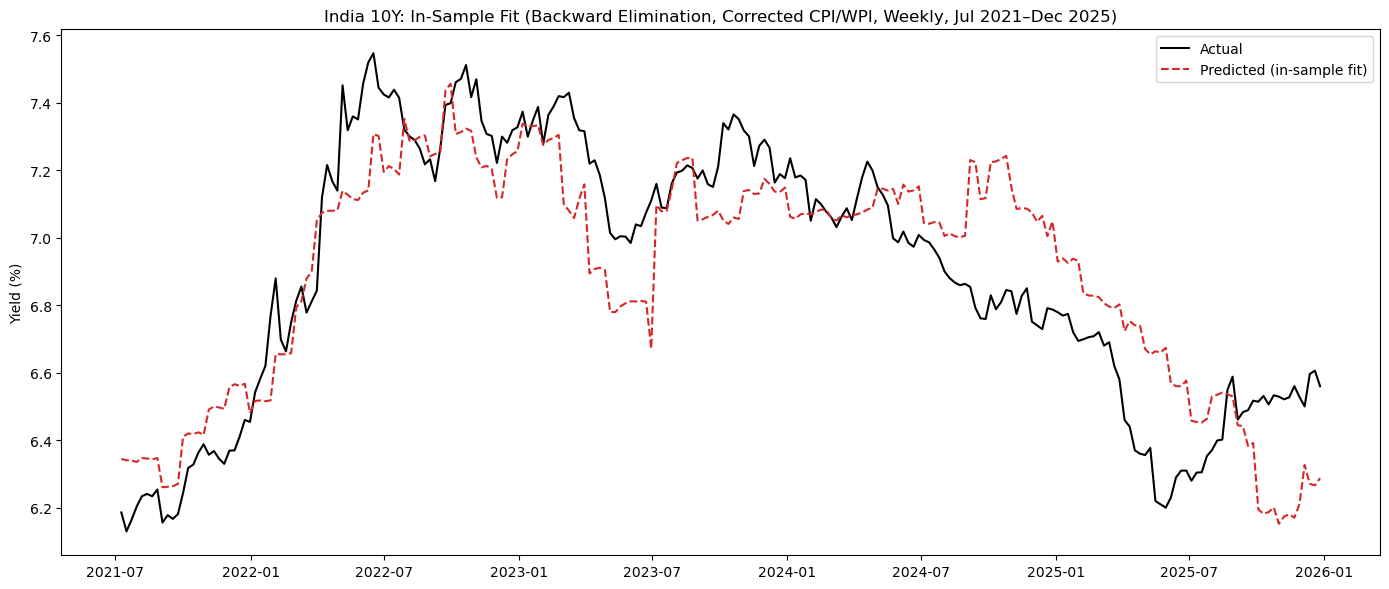

In-sample RMSE: 0.2005


In [15]:
fitted_values = final_model_backward.predict(sm.add_constant(final_vars_backward))

plt.figure(figsize=(14,6))
plt.plot(weekly_matrix_trimmed.index, y_trimmed, label='Actual', color='black', linewidth=1.5)
plt.plot(weekly_matrix_trimmed.index, fitted_values, label='Predicted (in-sample fit)', color='tab:red', linestyle='--')
plt.title('India 10Y: In-Sample Fit (Backward Elimination, Corrected CPI/WPI, Weekly, Jul 2021–Dec 2025)')
plt.ylabel('Yield (%)')
plt.legend()
plt.tight_layout()
plt.show()

in_sample_rmse = np.sqrt(mean_squared_error(y_trimmed, fitted_values))
print(f"In-sample RMSE: {in_sample_rmse:.4f}")

In [16]:
coefs = final_model_backward.params.to_dict()
model_vars = list(final_vars_backward.columns)

print("Final model variables:", model_vars)
print("\nFitted formula:")
formula = f"india_10y = {coefs['const']:.4f}"
for var in model_vars:
    sign = '+' if coefs[var] >= 0 else '-'
    formula += f" {sign} {abs(coefs[var]):.4f}*{var}"
print(formula)

print("\nCoefficients:")
for var in ['const'] + model_vars:
    print(f"  {var:12s} = {coefs[var]:.6f}")

Final model variables: ['m3_growth', 'us_10y', 'sofr', 'cpi', 'wpi']

Fitted formula:
india_10y = 5.4344 - 0.0467*m3_growth + 0.0706*us_10y + 0.2289*sofr + 0.1255*cpi + 0.0524*wpi

Coefficients:
  const        = 5.434438
  m3_growth    = -0.046745
  us_10y       = 0.070623
  sofr         = 0.228926
  cpi          = 0.125541
  wpi          = 0.052386


In [17]:
target_date = pd.Timestamp('2026-03-06')

# real values for this date, verified against source files and confirmed by you
real_inputs = {
    'm3_growth': 15.269540,   # Mar-2026, m3_growth.xlsx
    'us_10y': 4.15,           # 2026-03-06, DGS10.xlsx (confirmed)
    'sofr': 3.65,             # 2026-03-06, SOFR.xlsx (confirmed)
    'cpi': 3.402702,          # Mar-2026, inflation_data.xlsx (recomputed)
    'wpi': 3.976143,          # Mar-2026, inflation_data.xlsx (recomputed)
}

X_target = pd.DataFrame([real_inputs])[model_vars]
X_target = sm.add_constant(X_target, has_constant='add')

point_forecast = final_model_backward.predict(X_target).values[0]

print(f"Forecast date: {target_date.date()}")
print("Inputs used:")
for k in model_vars:
    print(f"  {k:12s} = {real_inputs[k]}")

print(f"\nPredicted india_10y: {point_forecast:.4f}%")

actual = 6.688  # real india_10y for 2026-03-06, verified by you
error = point_forecast - actual
print(f"Actual india_10y:    {actual}%")
print(f"Error (predicted - actual): {error:+.4f}  ({error/actual*100:+.2f}%)")

Forecast date: 2026-03-06
Inputs used:
  m3_growth    = 15.26954
  us_10y       = 4.15
  sofr         = 3.65
  cpi          = 3.402702
  wpi          = 3.976143

Predicted india_10y: 6.4848%
Actual india_10y:    6.688%
Error (predicted - actual): -0.2032  (-3.04%)


In [18]:
target_date = pd.Timestamp('2026-04-01')

# real values for this date, verified against source files
real_inputs = {
    'cpi': 3.484938,          # Apr-2026, inflation_data.xlsx (recomputed)
    'sofr': 3.65,             # 2026-04-01, SOFR.xlsx
    'us_10y': 4.33,           # 2026-04-01, DGS10.xlsx
    'm3_growth': 12.787560,   # Apr-2026, m3_growth.xlsx
    'wpi': 8.358209,          # Apr-2026, inflation_data.xlsx (recomputed)
}

X_target = pd.DataFrame([real_inputs])[model_vars]
X_target = sm.add_constant(X_target, has_constant='add')

point_forecast = final_model_backward.predict(X_target).values[0]

print(f"Forecast date: {target_date.date()}")
print("Inputs used:")
for k in model_vars:
    print(f"  {k:12s} = {real_inputs[k]}")

print(f"\nPredicted india_10y: {point_forecast:.4f}%")

actual = 6.960  
error = point_forecast - actual
print(f"Actual india_10y:    {actual}%")
print(f"Error (predicted - actual): {error:+.4f}  ({error/actual*100:+.2f}%)")

Forecast date: 2026-04-01
Inputs used:
  m3_growth    = 12.78756
  us_10y       = 4.33
  sofr         = 3.65
  cpi          = 3.484938
  wpi          = 8.358209

Predicted india_10y: 6.8534%
Actual india_10y:    6.96%
Error (predicted - actual): -0.1066  (-1.53%)


In [19]:
target_date = pd.Timestamp('2026-02-03')

real_inputs = {
    'cpi': 3.207659,
    'sofr': 3.69,
    'us_10y': 4.28,
    'm3_growth': 12.577414,
    'wpi': 2.180377,
}

X_target = pd.DataFrame([real_inputs])[model_vars]
X_target = sm.add_constant(X_target, has_constant='add')

point_forecast = final_model_backward.predict(X_target).values[0]

print(f"Forecast date: {target_date.date()}")
print("Inputs used:")
for k in model_vars:
    print(f"  {k:12s} = {real_inputs[k]}")

print(f"\nPredicted india_10y: {point_forecast:.4f}%")

actual = 6.721
error = point_forecast - actual
print(f"Actual india_10y:    {actual}%")
print(f"Error (predicted - actual): {error:+.4f}  ({error/actual*100:+.2f}%)")

Forecast date: 2026-02-03
Inputs used:
  m3_growth    = 12.577414
  us_10y       = 4.28
  sofr         = 3.69
  cpi          = 3.207659
  wpi          = 2.180377

Predicted india_10y: 6.5104%
Actual india_10y:    6.721%
Error (predicted - actual): -0.2106  (-3.13%)


In [20]:
!pip install "nbconvert[webpdf]" playwright --quiet
!playwright install chromium
!jupyter nbconvert --to webpdf "gsec data-Copy2.ipynb"

|                                                                                |   0% of 191.8 MiB
|â– â– â– â– â– â– â– â–                                                                         |  10% of 191.8 MiB
|â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â–                                                                 |  20% of 191.8 MiB
|â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â–                                                         |  30% of 191.8 MiB
|â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â–                                                 |  40% of 191.8 MiB
|â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â–                                         |  50% of 191.8 MiB
|â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â–          

[NbConvertApp] Converting notebook gsec data-Copy2.ipynb to webpdf
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Building PDF
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 184977 bytes to gsec data-Copy2.pdf
